<a href="https://colab.research.google.com/github/Rona-w/Data-Projects/blob/main/machine_learning_online_job_adverts.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as st
from sklearn import ensemble, tree, linear_model
import missingno as msno

In [198]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

In [199]:
data = pd.read_csv('online_job_adverts.csv')

In [200]:
data

,Region,SOC 2 digit code,SOC 2 digit label,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,East Midlands,11,Corporate managers and directors,high,2315,1955.0,2380,1950.0,2210.0,2080,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,East Midlands,12,Other managers and proprietors,low,1420,1240.0,1465,1250.0,1475.0,1555,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,East Midlands,21,"Science, research, engineering and technology ...",low,5010,4165.0,5170,4775.0,5130.0,4580,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,East Midlands,22,Health professionals,high,2565,2020.0,2670,2515.0,2890.0,2655,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,East Midlands,23,Teaching and other educational professionals,low,2075,1850.0,2160,1670.0,1940.0,2200,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Yorkshire and The Humber,81,"Process, plant and machine operatives",low,1635,1600.0,2190,1985.0,2125.0,2175,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,Yorkshire and The Humber,82,Transport and mobile machine drivers and opera...,high,1435,1280.0,1735,1685.0,1870.0,2290,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,Yorkshire and The Humber,91,Elementary trades and related occupations,low,490,590.0,845,660.0,855.0,845,...,375.0,340,555,425,465,740.0,855,775,910,875
241,Yorkshire and The Humber,92,Elementary administration and service occupations,high,2610,2960.0,3825,3680.0,3945.0,5215,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [201]:
data.describe()

,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,Oct-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
count,243.000000,242.000000,243.000000,242.000000,241.000000,243.000000,243.000000,242.000000,243.000000,243.000000,...,242.000000,243.000000,243.000000,243.000000,243.000000,242.000000,243.000000,243.000000,243.000000,243.000000
mean,3602.798354,2998.161157,3721.646091,3322.500000,3602.593361,3820.534979,3014.855967,3084.256198,2960.370370,3009.032922,...,2386.694215,2161.790123,2890.061728,2423.477366,2375.493827,2840.516529,2999.794239,2674.444444,2779.670782,2525.329218
std,5116.986073,4050.109781,4913.648323,4330.203757,4632.923305,5029.753757,3894.348692,4014.044595,3834.929216,3996.884943,...,2611.252824,2461.885697,3118.164010,2569.860261,2421.253680,2802.025690,2888.035657,2543.547703,2618.224805,2370.837347
min,5.000000,5.000000,10.000000,10.000000,10.000000,10.000000,5.000000,5.000000,5.000000,5.000000,...,10.000000,5.000000,10.000000,10.000000,5.000000,10.000000,10.000000,10.000000,10.000000,5.000000
25%,830.000000,791.250000,1072.500000,906.250000,1015.000000,990.000000,830.000000,845.000000,815.000000,800.000000,...,635.000000,587.500000,817.500000,702.500000,692.500000,882.500000,952.500000,880.000000,912.500000,847.500000
50%,2215.000000,1845.000000,2385.000000,2122.500000,2320.000000,2370.000000,1925.000000,1935.000000,1835.000000,1900.000000,...,1622.500000,1290.000000,1870.000000,1635.000000,1645.000000,2095.000000,2325.000000,2090.000000,2200.000000,1930.000000
75%,4222.500000,3792.500000,4645.000000,4123.750000,4540.000000,4657.500000,3822.500000,3943.750000,3750.000000,3777.500000,...,3345.000000,3107.500000,4107.500000,3520.000000,3490.000000,4085.000000,4337.500000,3802.500000,3995.000000,3610.000000
max,42550.000000,32765.000000,40125.000000,34730.000000,36560.000000,41000.000000,31105.000000,31625.000000,30080.000000,30105.000000,...,17255.000000,16655.000000,20460.000000,17250.000000,15470.000000,17130.000000,17690.000000,15570.000000,15445.000000,14215.000000


#Task 2: EDA

Missing Values: Msno.Matrix

<Axes: >

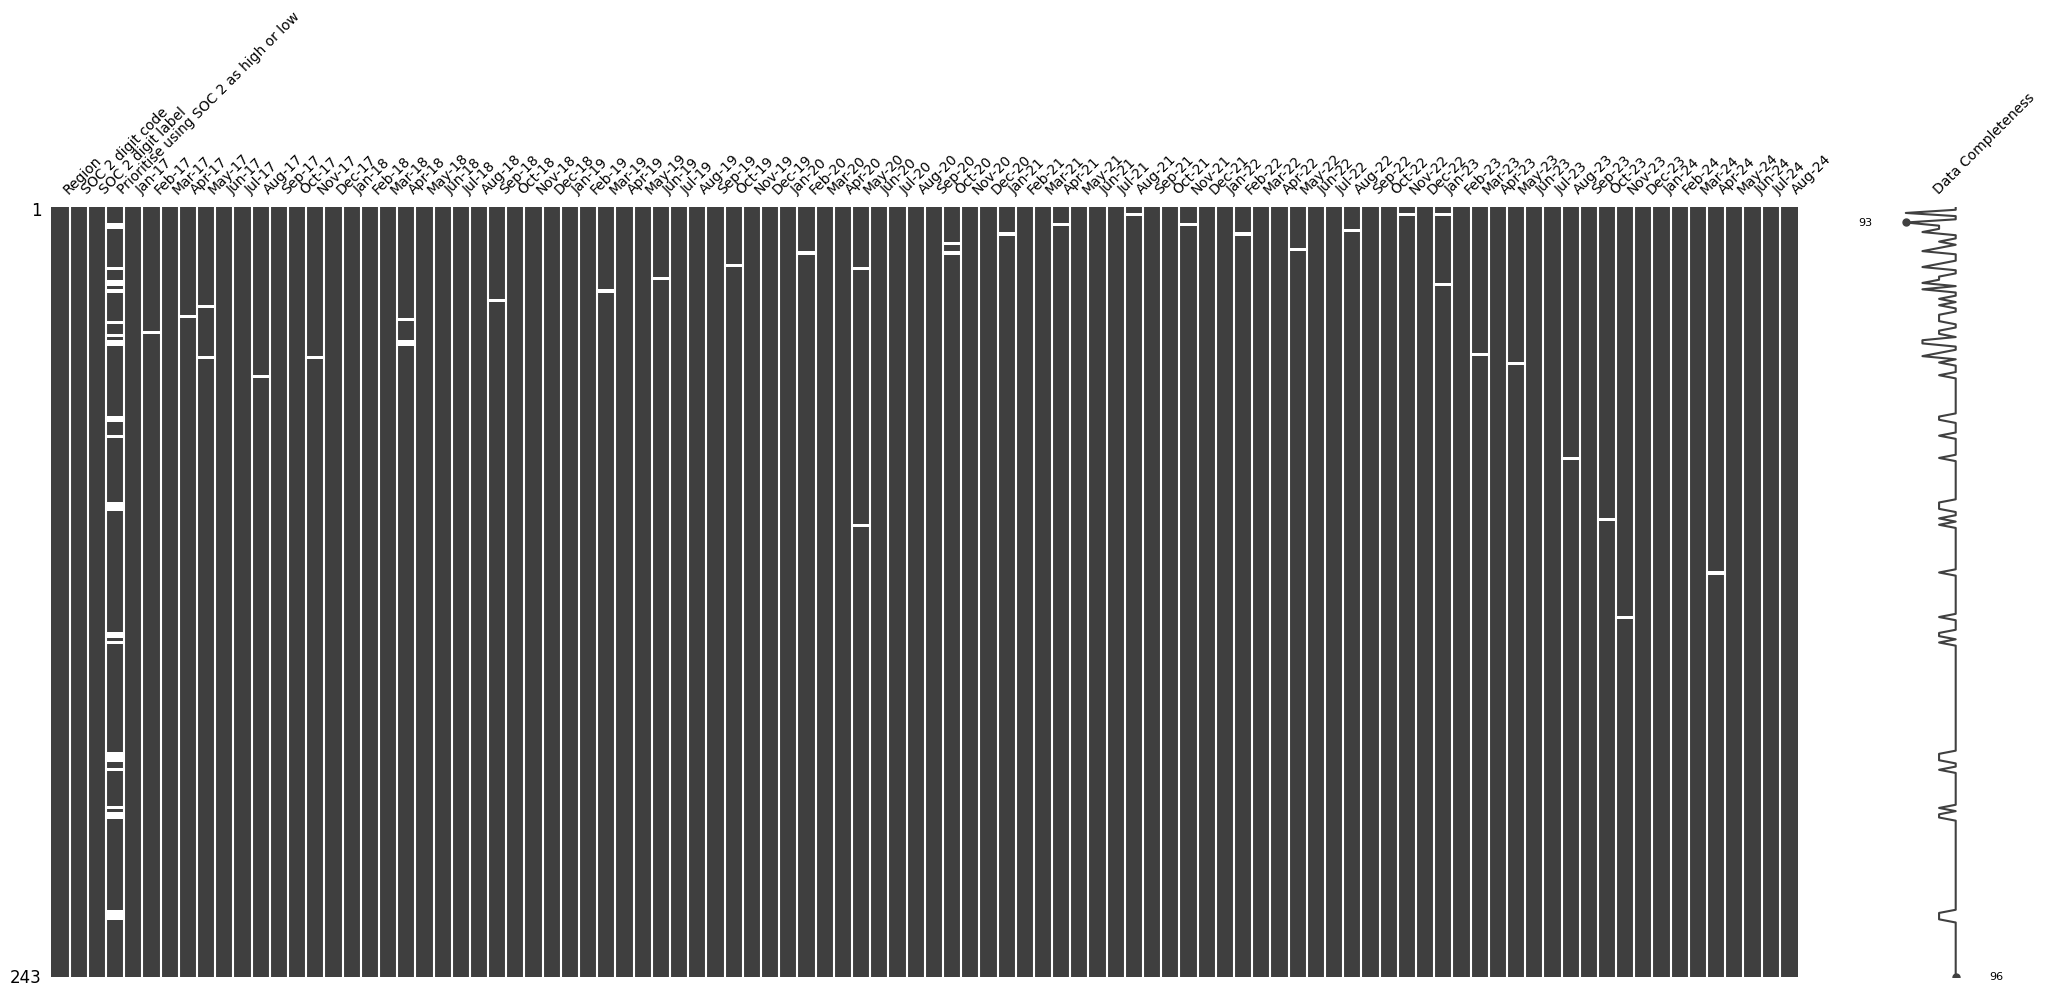

In [202]:
msno.matrix(data, fontsize=10, labels=True)

Box Plot (outlier detection)

/tmp/ipython-input-2803008091.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data[selected], labels=selected)


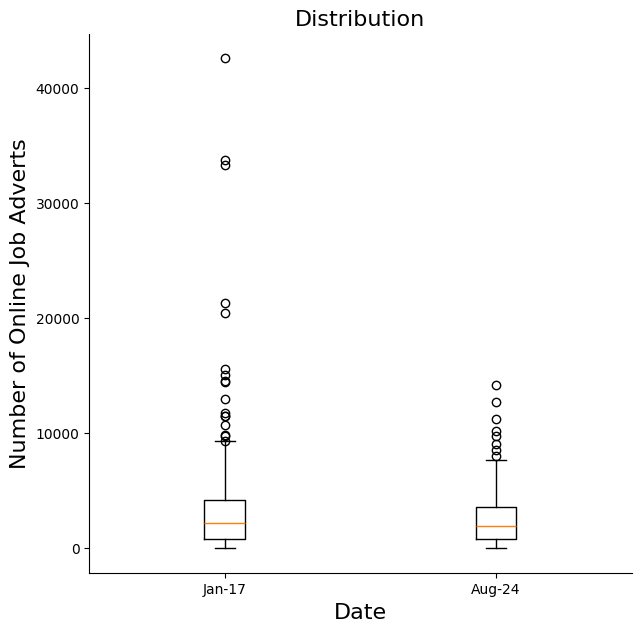

In [203]:
selected = ['Jan-17', 'Aug-24']

plt.figure(figsize=(7, 7))
# data[selected].boxplot()
plt.boxplot(data[selected], labels=selected)
plt.xlabel('Date', fontsize=16)
plt.ylabel('Number of Online Job Adverts', fontsize=16)
plt.title('Distribution', fontsize=16)

for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)

plt.show()

In [204]:
data['Dec-17'] = pd.to_numeric(data['Dec-17'], errors='coerce')
data['Apr-20'] = pd.to_numeric(data['Apr-20'], errors='coerce')
data['May-20'] = pd.to_numeric(data['May-20'], errors = 'coerce')
data['Jun-20'] = pd.to_numeric(data['Jun-20'], errors = 'coerce')

In [205]:
numeric_features = data.select_dtypes(include=[np.number])

numeric_features.columns

Index(['Jan-17', 'Feb-17', 'Mar-17', 'Apr-17', 'May-17', 'Jun-17', 'Jul-17',
       'Aug-17', 'Sep-17', 'Oct-17', 'Nov-17', 'Dec-17', 'Jan-18', 'Feb-18',
       'Mar-18', 'Apr-18', 'May-18', 'Jun-18', 'Jul-18', 'Aug-18', 'Sep-18',
       'Oct-18', 'Nov-18', 'Dec-18', 'Jan-19', 'Feb-19', 'Mar-19', 'Apr-19',
       'May-19', 'Jun-19', 'Jul-19', 'Aug-19', 'Sep-19', 'Oct-19', 'Nov-19',
       'Dec-19', 'Jan-20', 'Feb-20', 'Mar-20', 'Apr-20', 'May-20', 'Jun-20',
       'Jul-20', 'Aug-20', 'Sep-20', 'Oct-20', 'Nov-20', 'Dec-20', 'Jan-21',
       'Feb-21', 'Mar-21', 'Apr-21', 'May-21', 'Jun-21', 'Jul-21', 'Aug-21',
       'Sep-21', 'Oct-21', 'Nov-21', 'Dec-21', 'Jan-22', 'Feb-22', 'Mar-22',
       'Apr-22', 'May-22', 'Jun-22', 'Jul-22', 'Aug-22', 'Sep-22', 'Oct-22',
       'Nov-22', 'Dec-22', 'Jan-23', 'Feb-23', 'Mar-23', 'Apr-23', 'May-23',
       'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23',
       'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24',

In [206]:
categorical_features = data.select_dtypes(include=[object])

categorical_features.columns

Index(['Region', 'SOC 2 digit code', 'SOC 2 digit label',
       'Prioritise using SOC 2 as high or low'],
      dtype='object')

In [207]:
numeric_features.corr()

,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,Oct-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
Jan-17,1.000000,0.996856,0.994637,0.992206,0.990051,0.984449,0.982328,0.985240,0.987182,0.987912,...,0.927033,0.939611,0.925855,0.915499,0.898250,0.871993,0.857546,0.851153,0.847125,0.841447
Feb-17,0.996856,1.000000,0.997807,0.996578,0.995337,0.992016,0.988955,0.990122,0.992942,0.992762,...,0.939857,0.951115,0.938736,0.930257,0.915364,0.891399,0.878374,0.872888,0.869292,0.863619
Mar-17,0.994637,0.997807,1.000000,0.997723,0.995802,0.993270,0.991763,0.993204,0.995146,0.992810,...,0.944329,0.952488,0.943420,0.936030,0.921011,0.899478,0.887273,0.881709,0.880331,0.876167
Apr-17,0.992206,0.996578,0.997723,1.000000,0.998192,0.993655,0.994135,0.995184,0.996521,0.996355,...,0.946051,0.955856,0.944597,0.937474,0.924246,0.903340,0.891128,0.885590,0.885086,0.883161
May-17,0.990051,0.995337,0.995802,0.998192,1.000000,0.992588,0.991493,0.992742,0.993874,0.993911,...,0.952116,0.961819,0.950324,0.943483,0.931150,0.910326,0.899358,0.893656,0.892163,0.888186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Apr-24,0.871993,0.891399,0.899478,0.903340,0.910326,0.916796,0.910697,0.902592,0.909408,0.894547,...,0.980742,0.967023,0.985081,0.991742,0.995509,1.000000,0.996796,0.995417,0.993698,0.984955
May-24,0.857546,0.878374,0.887273,0.891128,0.899358,0.907590,0.899278,0.889433,0.897713,0.880892,...,0.972006,0.955836,0.975700,0.985184,0.991221,0.996796,1.000000,0.997988,0.994375,0.985115
Jun-24,0.851153,0.872888,0.881709,0.885590,0.893656,0.903289,0.895137,0.884872,0.892956,0.875142,...,0.968932,0.952137,0.972467,0.982019,0.988763,0.995417,0.997988,1.000000,0.995778,0.986195
Jul-24,0.847125,0.869292,0.880331,0.885086,0.892163,0.901687,0.898412,0.888898,0.894256,0.876668,...,0.967788,0.947585,0.971418,0.978710,0.984068,0.993698,0.994375,0.995778,1.000000,0.995106


In [208]:
numeric_features.corr()

,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,Oct-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
Jan-17,1.000000,0.996856,0.994637,0.992206,0.990051,0.984449,0.982328,0.985240,0.987182,0.987912,...,0.927033,0.939611,0.925855,0.915499,0.898250,0.871993,0.857546,0.851153,0.847125,0.841447
Feb-17,0.996856,1.000000,0.997807,0.996578,0.995337,0.992016,0.988955,0.990122,0.992942,0.992762,...,0.939857,0.951115,0.938736,0.930257,0.915364,0.891399,0.878374,0.872888,0.869292,0.863619
Mar-17,0.994637,0.997807,1.000000,0.997723,0.995802,0.993270,0.991763,0.993204,0.995146,0.992810,...,0.944329,0.952488,0.943420,0.936030,0.921011,0.899478,0.887273,0.881709,0.880331,0.876167
Apr-17,0.992206,0.996578,0.997723,1.000000,0.998192,0.993655,0.994135,0.995184,0.996521,0.996355,...,0.946051,0.955856,0.944597,0.937474,0.924246,0.903340,0.891128,0.885590,0.885086,0.883161
May-17,0.990051,0.995337,0.995802,0.998192,1.000000,0.992588,0.991493,0.992742,0.993874,0.993911,...,0.952116,0.961819,0.950324,0.943483,0.931150,0.910326,0.899358,0.893656,0.892163,0.888186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Apr-24,0.871993,0.891399,0.899478,0.903340,0.910326,0.916796,0.910697,0.902592,0.909408,0.894547,...,0.980742,0.967023,0.985081,0.991742,0.995509,1.000000,0.996796,0.995417,0.993698,0.984955
May-24,0.857546,0.878374,0.887273,0.891128,0.899358,0.907590,0.899278,0.889433,0.897713,0.880892,...,0.972006,0.955836,0.975700,0.985184,0.991221,0.996796,1.000000,0.997988,0.994375,0.985115
Jun-24,0.851153,0.872888,0.881709,0.885590,0.893656,0.903289,0.895137,0.884872,0.892956,0.875142,...,0.968932,0.952137,0.972467,0.982019,0.988763,0.995417,0.997988,1.000000,0.995778,0.986195
Jul-24,0.847125,0.869292,0.880331,0.885086,0.892163,0.901687,0.898412,0.888898,0.894256,0.876668,...,0.967788,0.947585,0.971418,0.978710,0.984068,0.993698,0.994375,0.995778,1.000000,0.995106


Heatmap

In [209]:
jan = ['Jan-17', 'Jan-18', 'Jan-19', 'Jan-20', 'Jan-21', 'Jan-22', 'Jan-23', 'Jan-24']

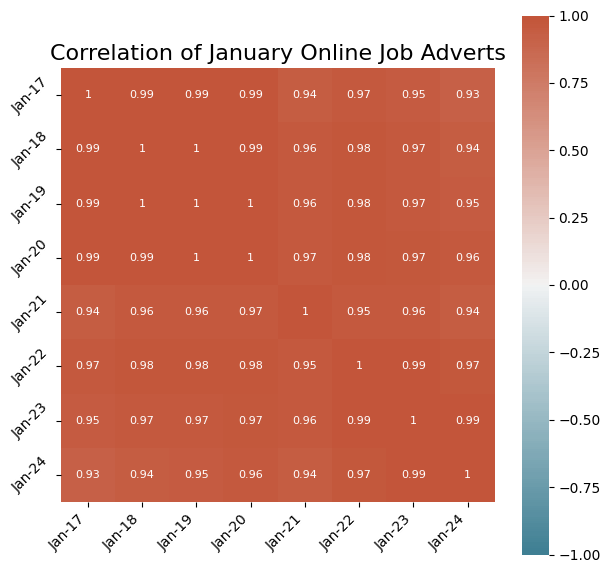

In [210]:
plt.figure(figsize=(7, 7))
corr = data[jan].corr()
ax = sns.heatmap(corr, vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(220, 20, n=200), square=True, annot=True,
                 annot_kws={"size": 8})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=45, horizontalalignment='right')
plt.title('Correlation of January Online Job Adverts', fontsize=16)
plt.show()

Violin Plot

To visualise distribution of numerical data, depict summary statistics and the density (non null) of each variable.

In [211]:
data['Aug-24'].max()

14215

<Figure size 800x800 with 0 Axes>

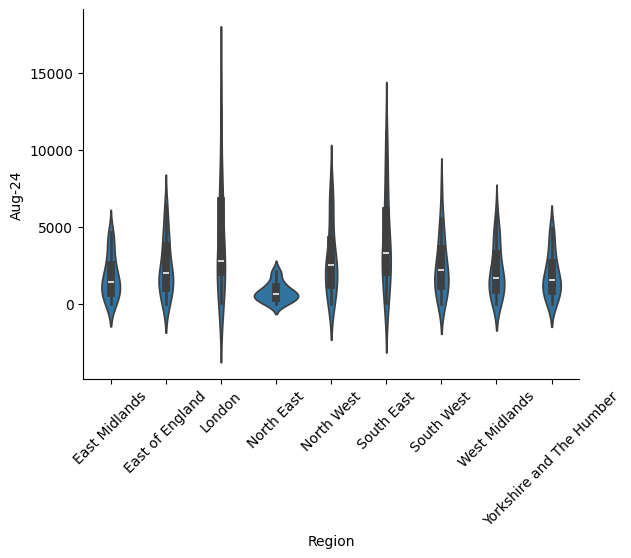

<Figure size 800x800 with 0 Axes>

In [212]:
sns.violinplot(x='Region',y= 'Aug-24', data = data)
plt.xticks(rotation=45)


for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
  if spine.spine_type != 'bottom' and spine.spine_type != 'left':
    spine.set_visible(False)
plt.figure(figsize=(8, 8))



Histogram (categorical variable is high low)

For high and low column frequency

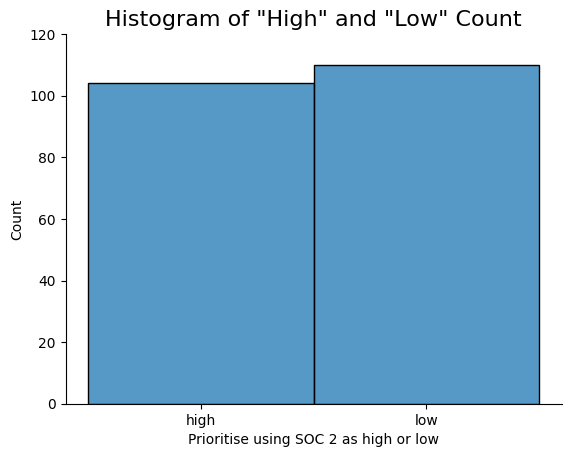

In [213]:
y = data['Prioritise using SOC 2 as high or low']
sns.histplot(y)
plt.ylim(0,120)
plt.title('Histogram of "High" and "Low" Count', fontsize=16)
for spine in plt.gca().spines.values():  # remove the frame, except the bottom and left
      if spine.spine_type != 'bottom' and spine.spine_type != 'left':
        spine.set_visible(False)

#Task 3: Data Pre-processing

##Replacing Missing values

Detecting missing values and calculating the sum

In [214]:
data.isnull().sum()

,0
Region,0
SOC 2 digit code,0
SOC 2 digit label,0
Prioritise using SOC 2 as high or low,29
Jan-17,0
...,...
Apr-24,1
May-24,0
Jun-24,0
Jul-24,0


Replacing categorical missing values with mode.

In [215]:
data['Prioritise using SOC 2 as high or low']

,Prioritise using SOC 2 as high or low
0,high
1,low
2,low
3,high
4,low
...,...
238,low
239,high
240,low
241,high


In [216]:
data['Prioritise using SOC 2 as high or low'].isnull().sum()

np.int64(29)

In [217]:
data['Prioritise using SOC 2 as high or low'].mode()

,Prioritise using SOC 2 as high or low
0,low


In [218]:
data['Prioritise using SOC 2 as high or low']

,Prioritise using SOC 2 as high or low
0,high
1,low
2,low
3,high
4,low
...,...
238,low
239,high
240,low
241,high


In [219]:
data['Prioritise using SOC 2 as high or low'] = data['Prioritise using SOC 2 as high or low'].fillna(data['Prioritise using SOC 2 as high or low'].mode()[0])

In [220]:
data['Prioritise using SOC 2 as high or low'].isnull().sum()

np.int64(0)

In [221]:
data['Prioritise using SOC 2 as high or low'].unique()

array(['high', 'low'], dtype=object)

In [222]:
data.shape

(243, 96)

Replacing numerical missing value with mean.

In [223]:
data['Apr-18'].isnull().sum()

np.int64(3)

In [224]:
data['Apr-18'].mean()

np.float64(2767.5416666666665)

In [225]:
data['Apr-18'] = data['Apr-18'].fillna(data['Apr-18'].mean())

In [226]:
data['Apr-18'].isnull().sum()

np.int64(0)

Fill rest of numerical data missing values with 0.

In [227]:
data.isnull().sum().nlargest()

,0
May-20,3
May-17,2
Oct-20,2
Jan-23,2
Feb-17,1


In [228]:
data.fillna((0), inplace = True)

In [229]:
data

,Region,SOC 2 digit code,SOC 2 digit label,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,East Midlands,11,Corporate managers and directors,high,2315,1955.0,2380,1950.0,2210.0,2080,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,East Midlands,12,Other managers and proprietors,low,1420,1240.0,1465,1250.0,1475.0,1555,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,East Midlands,21,"Science, research, engineering and technology ...",low,5010,4165.0,5170,4775.0,5130.0,4580,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,East Midlands,22,Health professionals,high,2565,2020.0,2670,2515.0,2890.0,2655,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,East Midlands,23,Teaching and other educational professionals,low,2075,1850.0,2160,1670.0,1940.0,2200,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Yorkshire and The Humber,81,"Process, plant and machine operatives",low,1635,1600.0,2190,1985.0,2125.0,2175,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,Yorkshire and The Humber,82,Transport and mobile machine drivers and opera...,high,1435,1280.0,1735,1685.0,1870.0,2290,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,Yorkshire and The Humber,91,Elementary trades and related occupations,low,490,590.0,845,660.0,855.0,845,...,375.0,340,555,425,465,740.0,855,775,910,875
241,Yorkshire and The Humber,92,Elementary administration and service occupations,high,2610,2960.0,3825,3680.0,3945.0,5215,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [230]:
data.isnull().sum()

,0
Region,0
SOC 2 digit code,0
SOC 2 digit label,0
Prioritise using SOC 2 as high or low,0
Jan-17,0
...,...
Apr-24,0
May-24,0
Jun-24,0
Jul-24,0


<Axes: >

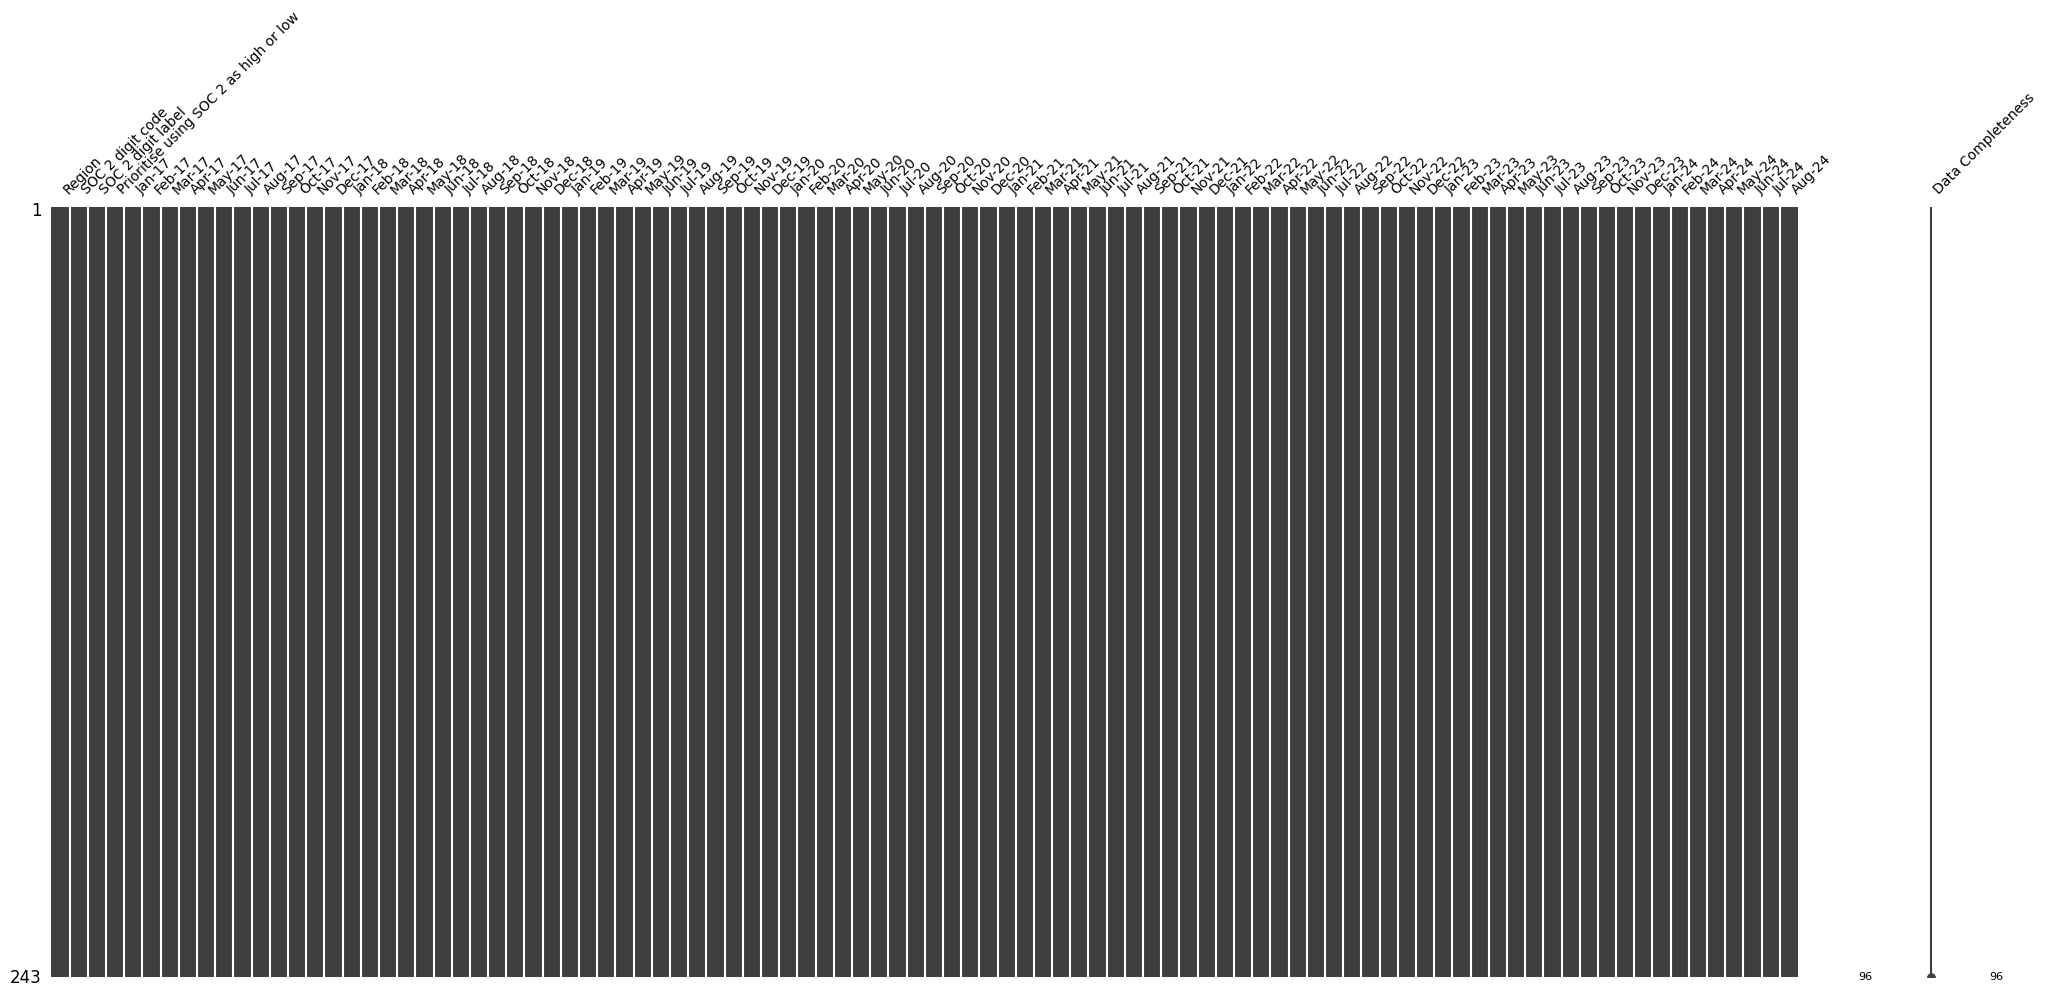

In [231]:
msno.matrix(data, fontsize=10, labels=True)

Replaces 'Unknown' String in 'SOC 2 digit code' to 0.

In [232]:
digit_code = data['SOC 2 digit code'].replace({'Unknown': 0}, inplace = True)


/tmp/ipython-input-3437962010.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  digit_code = data['SOC 2 digit code'].replace({'Unknown': 0}, inplace = True)


In [233]:
data['SOC 2 digit code']

,SOC 2 digit code
0,11
1,12
2,21
3,22
4,23
...,...
238,81
239,82
240,91
241,92


##MinMax Scalling

In [234]:
aug_24_copy = data['Aug-24'].copy()

In [235]:
aug_24_copy

,Aug-24
0,1565
1,1295
2,2270
3,2635
4,1560
...,...
238,2255
239,2480
240,875
241,4875


In [236]:
aug_24_minmax = (aug_24_copy - aug_24_copy.min()) / (aug_24_copy.max() - aug_24_copy.min())

aug_24_minmax.head(10)

,Aug-24
0,0.109782
1,0.090781
2,0.159395
3,0.185081
4,0.109430
5,0.174525
6,0.122449
7,0.101689
8,0.006685
9,0.041872


In [237]:
data['Aug-24']

,Aug-24
0,1565
1,1295
2,2270
3,2635
4,1560
...,...
238,2255
239,2480
240,875
241,4875


##Encoding - label encoding and one hot encoding

In [238]:
pip install category_encoders

In [239]:
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce

In [240]:
#One-Hot Encoding

encoder=ce.OneHotEncoder(cols='Region',handle_unknown='return_nan',return_df=True,use_cat_names=True)

region_encoded = encoder.fit_transform(data['Region'])

In [241]:
region_encoded

,Region_East Midlands,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [242]:
data['Prioritise using SOC 2 as high or low']

,Prioritise using SOC 2 as high or low
0,high
1,low
2,low
3,high
4,low
...,...
238,low
239,high
240,low
241,high


In [243]:
data['Prioritise using SOC 2 as high or low'] = data['Prioritise using SOC 2 as high or low'].astype("string")

In [244]:
data['Prioritise using SOC 2 as high or low'].unique()

<StringArray>
['high', 'low']
Length: 2, dtype: string

In [245]:
# Apply LabelEncoder
le = LabelEncoder()
data['Prioritise using SOC 2 as high or low'] = le.fit_transform(data['Prioritise using SOC 2 as high or low'])

print(data['Prioritise using SOC 2 as high or low'])

0      0
1      1
2      1
3      0
4      1
      ..
238    1
239    0
240    1
241    0
242    0
Name: Prioritise using SOC 2 as high or low, Length: 243, dtype: int64


In [246]:
data['Prioritise using SOC 2 as high or low'].max()

1

In [247]:
data['Prioritise using SOC 2 as high or low'].min()

0

In [248]:
data

,Region,SOC 2 digit code,SOC 2 digit label,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,East Midlands,11,Corporate managers and directors,0,2315,1955.0,2380,1950.0,2210.0,2080,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,East Midlands,12,Other managers and proprietors,1,1420,1240.0,1465,1250.0,1475.0,1555,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,East Midlands,21,"Science, research, engineering and technology ...",1,5010,4165.0,5170,4775.0,5130.0,4580,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,East Midlands,22,Health professionals,0,2565,2020.0,2670,2515.0,2890.0,2655,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,East Midlands,23,Teaching and other educational professionals,1,2075,1850.0,2160,1670.0,1940.0,2200,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Yorkshire and The Humber,81,"Process, plant and machine operatives",1,1635,1600.0,2190,1985.0,2125.0,2175,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,Yorkshire and The Humber,82,Transport and mobile machine drivers and opera...,0,1435,1280.0,1735,1685.0,1870.0,2290,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,Yorkshire and The Humber,91,Elementary trades and related occupations,1,490,590.0,845,660.0,855.0,845,...,375.0,340,555,425,465,740.0,855,775,910,875
241,Yorkshire and The Humber,92,Elementary administration and service occupations,0,2610,2960.0,3825,3680.0,3945.0,5215,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


#Task 4: Supervised ML algorithm - Prediction using Linear Regression Model

(predicting August-24 Advert Count)

Linear regression is used as it's a predictive model.

Creating a copy of the dataset.

In [249]:
df = data.copy()

In [250]:
df

,Region,SOC 2 digit code,SOC 2 digit label,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,East Midlands,11,Corporate managers and directors,0,2315,1955.0,2380,1950.0,2210.0,2080,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,East Midlands,12,Other managers and proprietors,1,1420,1240.0,1465,1250.0,1475.0,1555,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,East Midlands,21,"Science, research, engineering and technology ...",1,5010,4165.0,5170,4775.0,5130.0,4580,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,East Midlands,22,Health professionals,0,2565,2020.0,2670,2515.0,2890.0,2655,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,East Midlands,23,Teaching and other educational professionals,1,2075,1850.0,2160,1670.0,1940.0,2200,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,Yorkshire and The Humber,81,"Process, plant and machine operatives",1,1635,1600.0,2190,1985.0,2125.0,2175,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,Yorkshire and The Humber,82,Transport and mobile machine drivers and opera...,0,1435,1280.0,1735,1685.0,1870.0,2290,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,Yorkshire and The Humber,91,Elementary trades and related occupations,1,490,590.0,845,660.0,855.0,845,...,375.0,340,555,425,465,740.0,855,775,910,875
241,Yorkshire and The Humber,92,Elementary administration and service occupations,0,2610,2960.0,3825,3680.0,3945.0,5215,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


Removing 'SOC 2 digit code' and 'SOC 2 digit label' from dataset.

Also remove non-encoded 'Region' column.

In [251]:
df = df.drop(['SOC 2 digit code', 'SOC 2 digit label', 'Region'], axis = 1)

In [252]:
df

,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,0,2315,1955.0,2380,1950.0,2210.0,2080,1665,1880.0,1720,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,1,1420,1240.0,1465,1250.0,1475.0,1555,1130,1145.0,1210,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,1,5010,4165.0,5170,4775.0,5130.0,4580,3730,3975.0,3920,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,0,2565,2020.0,2670,2515.0,2890.0,2655,2315,2415.0,2250,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,1,2075,1850.0,2160,1670.0,1940.0,2200,1225,1320.0,1495,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1,1635,1600.0,2190,1985.0,2125.0,2175,1775,1865.0,1710,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,0,1435,1280.0,1735,1685.0,1870.0,2290,1840,1905.0,1710,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,1,490,590.0,845,660.0,855.0,845,815,810.0,790,...,375.0,340,555,425,465,740.0,855,775,910,875
241,0,2610,2960.0,3825,3680.0,3945.0,5215,3760,3150.0,3280,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


Add one hot encoded 'Region' column to dataset.

In [253]:
region_encoded

,Region_East Midlands,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [254]:
df

,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,0,2315,1955.0,2380,1950.0,2210.0,2080,1665,1880.0,1720,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,1,1420,1240.0,1465,1250.0,1475.0,1555,1130,1145.0,1210,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,1,5010,4165.0,5170,4775.0,5130.0,4580,3730,3975.0,3920,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,0,2565,2020.0,2670,2515.0,2890.0,2655,2315,2415.0,2250,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,1,2075,1850.0,2160,1670.0,1940.0,2200,1225,1320.0,1495,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1,1635,1600.0,2190,1985.0,2125.0,2175,1775,1865.0,1710,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,0,1435,1280.0,1735,1685.0,1870.0,2290,1840,1905.0,1710,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,1,490,590.0,845,660.0,855.0,845,815,810.0,790,...,375.0,340,555,425,465,740.0,855,775,910,875
241,0,2610,2960.0,3825,3680.0,3945.0,5215,3760,3150.0,3280,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [255]:
df = region_encoded.merge(df, left_index=True, right_index=True)

In [256]:
df

,Region_East Midlands,Region_East of England,Region_London,Region_North East,Region_North West,Region_South East,Region_South West,Region_West Midlands,Region_Yorkshire and The Humber,Prioritise using SOC 2 as high or low,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,...,375.0,340,555,425,465,740.0,855,775,910,875
241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [257]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
#all but last column

In [258]:
X

array([[1.00e+00, 0.00e+00, 0.00e+00, ..., 1.87e+03, 1.61e+03, 1.83e+03],
       [1.00e+00, 0.00e+00, 0.00e+00, ..., 1.44e+03, 1.33e+03, 1.28e+03],
       [1.00e+00, 0.00e+00, 0.00e+00, ..., 2.64e+03, 2.27e+03, 2.32e+03],
       ...,
       [0.00e+00, 0.00e+00, 0.00e+00, ..., 8.55e+02, 7.75e+02, 9.10e+02],
       [0.00e+00, 0.00e+00, 0.00e+00, ..., 4.98e+03, 4.60e+03, 4.91e+03],
       [0.00e+00, 0.00e+00, 0.00e+00, ..., 3.50e+01, 2.50e+01, 4.00e+01]])

In [259]:
y

array([ 1565,  1295,  2270,  2635,  1560,  2485,  1745,  1450,   100,
         600,  4460,  3995,   645,   145,  3380,   930,  1335,  4130,
         650,    20,  1405,   880,  2385,  3100,   860,  4675,    15,
        2130,  1815,  3160,  4000,  1565,  3675,  2240,  1885,   165,
         890,  5885,  4745,   950,   305,  4215,  1425,  2015,  5415,
         955,    40,  2060,  1165,  2680,  3830,  1350,  6530,    60,
        6580,  3185,  9750,  6920,  4870, 12680,  3835,  3545,   470,
        2300, 14215,  7670,  2285,   295,  4185,  2275,  2795,  7030,
        2020,    65,  2350,  1170,  2455,  2230,   925,  6815,   120,
         600,   490,  1060,  1255,   680,  1245,   835,   740,    55,
         315,  1930,  1550,   435,    55,  1320,   400,   645,  2185,
         365,    15,   810,   425,   770,   835,   305,  2090,     5,
        2820,  2080,  4090,  4845,  2615,  5810,  2600,  2455,   200,
        1190,  7985,  6420,  1315,   185,  4270,  1330,  2140,  6705,
        1220,    50,

In [260]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
#The random_state is a pseudo-random number parameter that allows you to reproduce the same train test split each time you run the code.

Training the model.

In [261]:
X_train.shape

(194, 101)

In [262]:
y_train.shape

(194,)

In [263]:
X_test.shape

(49, 101)

In [264]:
y_test.shape

(49,)

In [265]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

Test the model on the testing set (“X_test” and “y_test” in the image) and evaluate the performance.

In [266]:
y_pred = regressor.predict(X_test)

In [267]:
y_pred

array([ 808.57, 1739.59, 9554.43, 1385.91, 2215.73,  327.71,   15.6 ,
       2417.64,  666.88, 6061.43, 1085.19, 1761.82, 4185.77,  109.79,
        429.1 ,   66.68, 1686.29, 1047.11, 2142.25,   27.95, 2310.95,
         15.78, 2920.57, 4282.77, 2907.42, 3492.98, 4290.57,   43.67,
        412.5 , 3342.62, 4999.62, 1316.17, 4805.04, 3602.74,  612.6 ,
       1167.67,  418.02, 1602.51, 5174.92,  800.75, 1032.77, 1250.49,
       2719.51, 1399.43, 2084.71,  351.44, 3986.4 , 4768.54, 1284.48])

In [268]:
regressor.intercept_

np.float64(-17.320531734237647)

In [269]:
regressor.coef_

array([ 7.09e+00,  2.05e+01,  2.25e+01, -1.33e+01, -3.56e+00, -2.34e+01,
       -2.32e+01, -5.80e+00,  1.92e+01, -4.27e+00,  1.71e-03,  2.69e-02,
       -1.08e-01,  4.51e-02,  2.26e-03, -1.14e-01,  1.38e-01,  9.71e-02,
       -9.11e-02,  1.44e-01,  3.72e-02, -8.82e-02,  8.07e-02, -1.19e-01,
        8.83e-03, -5.81e-03, -1.11e-01,  1.82e-01, -1.33e-01, -4.36e-02,
        6.85e-03, -8.73e-02, -2.48e-02, -8.56e-02,  2.88e-02,  3.17e-03,
        1.40e-01,  1.06e-01, -1.11e-01,  2.28e-02, -5.83e-02, -6.81e-02,
        1.26e-01, -5.30e-02,  6.31e-02,  3.45e-02,  2.80e-02,  1.08e-02,
       -6.28e-02,  1.66e-01, -2.00e-01, -6.43e-03,  3.59e-02, -5.75e-02,
        1.70e-01, -3.13e-02,  1.63e-01, -2.45e-01,  4.47e-02, -9.71e-02,
        1.64e-01,  8.08e-02, -1.20e-01, -1.26e-01,  1.90e-02,  1.05e-01,
        1.05e-01,  1.06e-01, -7.90e-02, -7.22e-02,  8.20e-03, -8.64e-02,
       -1.42e-01,  2.29e-01,  4.33e-02, -7.28e-02,  5.28e-02,  1.34e-03,
        6.00e-02, -5.40e-02, -1.21e-01, -6.87e-02, 

Linear Regression Performance Metrics:

Mean Absolute Error

In [270]:
from sklearn.metrics import mean_absolute_error

In [271]:
# MAE
mae = mean_absolute_error(y_test, y_pred)
print("MAE --> ", mae)

MAE -->  102.09945765367019


To view the original y values and predicted y values

In [272]:
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[ 808.57  860.  ]
 [1739.59 1745.  ]
 [9554.43 9055.  ]
 [1385.91 1430.  ]
 [2215.73 2255.  ]
 [ 327.71  275.  ]
 [  15.6    35.  ]
 [2417.64 2580.  ]
 [ 666.88  600.  ]
 [6061.43 5810.  ]
 [1085.19  955.  ]
 [1761.82 1735.  ]
 [4185.77 4100.  ]
 [ 109.79  200.  ]
 [ 429.1   490.  ]
 [  66.68   95.  ]
 [1686.29 1560.  ]
 [1047.11  930.  ]
 [2142.25 2285.  ]
 [  27.95   50.  ]
 [2310.95 2240.  ]
 [  15.78   20.  ]
 [2920.57 2820.  ]
 [4282.77 4000.  ]
 [2907.42 3125.  ]
 [3492.98 3390.  ]
 [4290.57 4460.  ]
 [  43.67   65.  ]
 [ 412.5   435.  ]
 [3342.62 3345.  ]
 [4999.62 4845.  ]
 [1316.17 1325.  ]
 [4805.04 4675.  ]
 [3602.74 3835.  ]
 [ 612.6   650.  ]
 [1167.67 1220.  ]
 [ 418.02  400.  ]
 [1602.51 1610.  ]
 [5174.92 5520.  ]
 [ 800.75  875.  ]
 [1032.77 1170.  ]
 [1250.49 1190.  ]
 [2719.51 2615.  ]
 [1399.43 1335.  ]
 [2084.71 2140.  ]
 [ 351.44  295.  ]
 [3986.4  4300.  ]
 [4768.54 4745.  ]
 [1284.48 1175.  ]]


In [273]:
y_pred = regressor.predict(X_test)

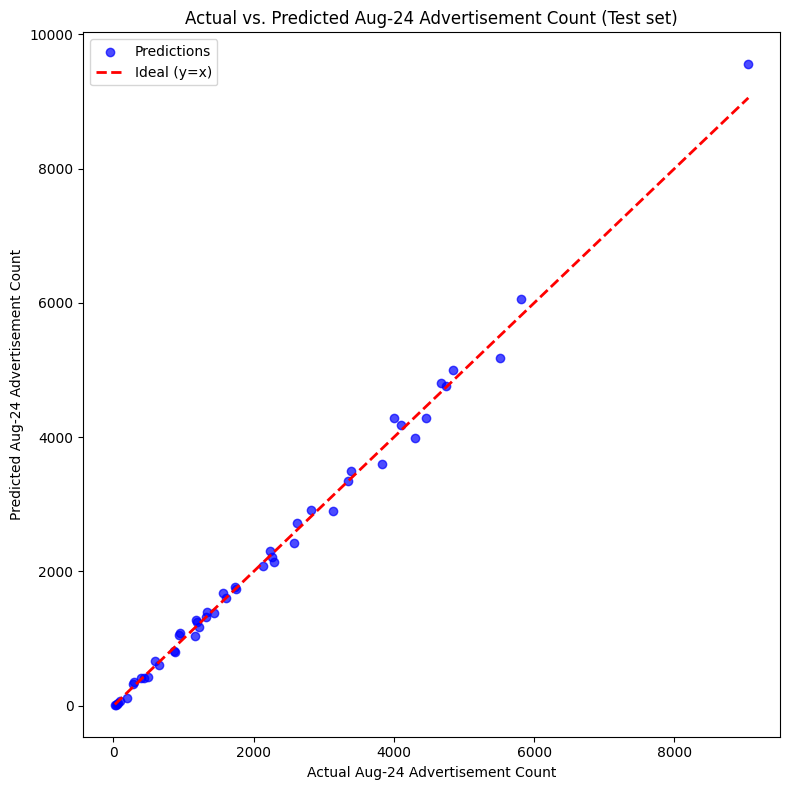

In [274]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color='blue', alpha=0.7, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal (y=x)')

plt.xlabel("Actual Aug-24 Advertisement Count")
plt.ylabel("Predicted Aug-24 Advertisement Count")
plt.title("Actual vs. Predicted Aug-24 Advertisement Count (Test set)")
plt.legend()
plt.tight_layout()
plt.show()

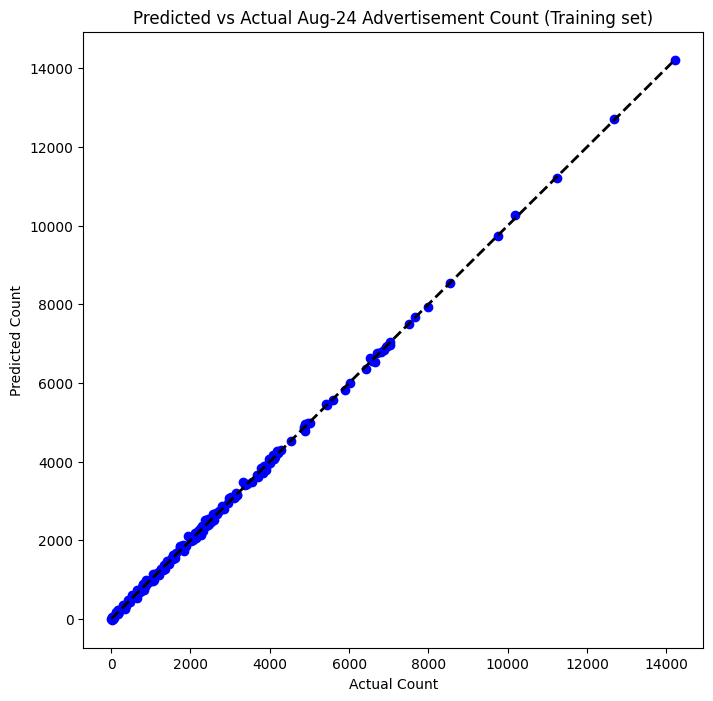

In [275]:
pred = regressor.predict(X_train)

plt.figure(figsize=(8, 8))
plt.scatter(y_train, pred, color='blue')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2) #draws line of best fit
plt.title("Predicted vs Actual Aug-24 Advertisement Count (Training set)")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.show()

In [276]:
y_train.min()

np.int64(5)

In [277]:
print(X_train.shape)
print(y_train.shape)

(194, 101)
(194,)


#Task 5: Supervised ML algorithm - Classification using Logistic Regression Classifier

Features: Jan-17 to Aug-24 as input variables.

Target variable: Prioritise using SOC 2 as high or low (label encoded)

In [278]:
df_class = data.drop(['SOC 2 digit code', 'SOC 2 digit label', 'Region'], axis = 1)

In [279]:
df_class

,Prioritise using SOC 2 as high or low,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,0,2315,1955.0,2380,1950.0,2210.0,2080,1665,1880.0,1720,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,1,1420,1240.0,1465,1250.0,1475.0,1555,1130,1145.0,1210,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,1,5010,4165.0,5170,4775.0,5130.0,4580,3730,3975.0,3920,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,0,2565,2020.0,2670,2515.0,2890.0,2655,2315,2415.0,2250,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,1,2075,1850.0,2160,1670.0,1940.0,2200,1225,1320.0,1495,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1,1635,1600.0,2190,1985.0,2125.0,2175,1775,1865.0,1710,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,0,1435,1280.0,1735,1685.0,1870.0,2290,1840,1905.0,1710,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,1,490,590.0,845,660.0,855.0,845,815,810.0,790,...,375.0,340,555,425,465,740.0,855,775,910,875
241,0,2610,2960.0,3825,3680.0,3945.0,5215,3760,3150.0,3280,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [280]:
X_class = df_class.drop(columns=['Prioritise using SOC 2 as high or low']) # Features
y_class = df_class['Prioritise using SOC 2 as high or low'] # Target

In [281]:
y_class

,Prioritise using SOC 2 as high or low
0,0
1,1
2,1
3,0
4,1
...,...
238,1
239,0
240,1
241,0


In [282]:
X_class

,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,Aug-17,Sep-17,Oct-17,...,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
0,2315,1955.0,2380,1950.0,2210.0,2080,1665,1880.0,1720,1915,...,1500.0,1400,1850,1525,1540,1785.0,1870,1610,1830,1565
1,1420,1240.0,1465,1250.0,1475.0,1555,1130,1145.0,1210,1220,...,1020.0,915,1295,1105,1050,1350.0,1440,1330,1275,1295
2,5010,4165.0,5170,4775.0,5130.0,4580,3730,3975.0,3920,4405,...,2445.0,2395,3045,2575,2510,2620.0,2635,2270,2315,2270
3,2565,2020.0,2670,2515.0,2890.0,2655,2315,2415.0,2250,2425,...,3300.0,2915,3380,2770,2845,3200.0,3260,2895,2965,2635
4,2075,1850.0,2160,1670.0,1940.0,2200,1225,1320.0,1495,1485,...,1700.0,1825,2135,2035,2270,2400.0,2805,2225,1945,1560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,1635,1600.0,2190,1985.0,2125.0,2175,1775,1865.0,1710,1745,...,1385.0,1280,1885,1570,1620,2160.0,2180,2120,2295,2255
239,1435,1280.0,1735,1685.0,1870.0,2290,1840,1905.0,1710,1650,...,1190.0,845,1265,1200,1145,1850.0,2345,2385,2575,2480
240,490,590.0,845,660.0,855.0,845,815,810.0,790,640,...,375.0,340,555,425,465,740.0,855,775,910,875
241,2610,2960.0,3825,3680.0,3945.0,5215,3760,3150.0,3280,3350,...,2840.0,2550,3955,3590,4005,4935.0,4985,4600,4910,4875


In [283]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_class = sc.fit_transform(X_class)

In [284]:
X_class

array([[-0.25, -0.26, -0.27, ..., -0.42, -0.36, -0.41],
       [-0.43, -0.43, -0.46, ..., -0.53, -0.58, -0.52],
       [ 0.28,  0.29,  0.3 , ..., -0.16, -0.18, -0.11],
       ...,
       [-0.61, -0.59, -0.59, ..., -0.75, -0.72, -0.7 ],
       [-0.19, -0.01,  0.02, ...,  0.76,  0.82,  0.99],
       [-0.69, -0.72, -0.74, ..., -1.04, -1.05, -1.06]])

In [285]:
# Split the data into training and testing sets
#The data is split into training (80%) and testing (20%) sets using train_test_split from sklearn.model_selection.
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

Training the classifier and trying to find the optimal iteration which is the lowest iteration number with convergence.

In [286]:
y_class_train

,Prioritise using SOC 2 as high or low
115,0
207,1
158,0
132,0
84,1
...,...
106,1
14,0
92,0
179,1


In [287]:
#Training the classifier
#from sklearn.ensemble import RandomForestClassifier
#classifier_lr = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier_lr = LogisticRegression(max_iter = 35, random_state=42)

In [288]:
classifier_lr.fit(X_class_train, y_class_train)

LogisticRegression(max_iter=35, random_state=42)

Confusion Matrix

In [289]:
# Predict probabilities for low class (class 1)
# = classifier_lr.predict_proba(X_class_test)[:, 1]

In [290]:
# Make predictions on the testing data
lr_predictions = classifier_lr.predict(X_class_test)

In [291]:
y_class

,Prioritise using SOC 2 as high or low
0,0
1,1
2,1
3,0
4,1
...,...
238,1
239,0
240,1
241,0



 Logistic Regression Confusion Matrix:


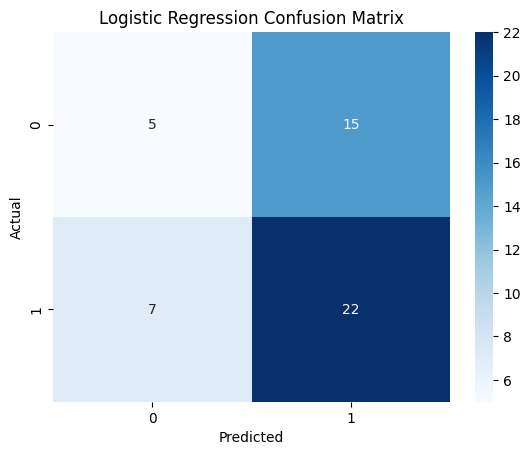

In [292]:
print("\n Logistic Regression Confusion Matrix:")
conf_matrix = confusion_matrix(y_class_test, lr_predictions)
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [293]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_class_test, lr_predictions)
print(cm)
accuracy_score(y_class_test, lr_predictions)
#pass test data and predicted data
#test sample to the right, predicted is left
#we want a true positive (tp) and true negative (tn). we can alse have false positive and positive negative (these are [parameters])

[[ 5 15]
 [ 7 22]]


0.5510204081632653

Classification Report

In [294]:
# Display classification report and confusion matrix
print("\nLogistic Regression Classification Report:")
print(classification_report(y_class_test, lr_predictions))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.25      0.31        20
           1       0.59      0.76      0.67        29

    accuracy                           0.55        49
   macro avg       0.51      0.50      0.49        49
weighted avg       0.52      0.55      0.52        49

